In [237]:
#!pip install scikit-learn

In [238]:
import pandas as pd
import datetime as dt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
from datetime import datetime

In [239]:
entity = 'SGP'
timezone = 'Singapore'

In [240]:
#Import the forecast results data
file_path_forecast = r"D:\Modelling\demandcast\demandcast\ml_models\results\forecasts\with_xgboost_model_20260527_155249\using_assembled_data_for_forecasting_20260527_155309\all_raw_normalized_20260527_155424.csv"
df_results = pd.read_csv(file_path_forecast)

In [241]:
#Import the training (original) data
file_path_training = r'D:\Modelling\demandcast\demandcast\data\assembled_raw_for_compare\assembled_data_for_training_20260527_155516_SGP_RAW.csv'
df_train = pd.read_csv(file_path_training)

In [242]:
df_results = df_results[df_results['Entity code']==entity]
df_train = df_train[df_train['Entity code']==entity]

In [243]:
start_date = '2023-12-31' 
end_date = '2026-01-01'

In [244]:
df_train = df_train[['Time (UTC)','Entity code','Load (MW)','Load (fraction of annual total)']]

#Only keep the 2024 - 2025 training values 
df_train = df_train[(df_train['Time (UTC)'] >= start_date) & (df_train['Time (UTC)']<= end_date)].reset_index(drop = True)

In [245]:
df_train

,Time (UTC),Entity code,Load (MW),Load (fraction of annual total)
0,2023-12-31 16:00:00,SGP,5692.586231,0.000095
1,2023-12-31 17:00:00,SGP,5629.490208,0.000094
2,2023-12-31 18:00:00,SGP,5528.700068,0.000093
3,2023-12-31 19:00:00,SGP,5365.430167,0.000090
4,2023-12-31 20:00:00,SGP,5262.971964,0.000088
...,...,...,...,...
17539,2025-12-31 11:00:00,SGP,7189.638850,0.000119
17540,2025-12-31 12:00:00,SGP,7101.195500,0.000118
17541,2025-12-31 13:00:00,SGP,6990.700450,0.000116
17542,2025-12-31 14:00:00,SGP,6784.926950,0.000112


In [246]:
df_results = df_results[['Time (UTC)','Entity code','Normalized forecast load fraction (%)','Forecast Load (MW)']]

In [247]:
df_results

,Time (UTC),Entity code,Normalized forecast load fraction (%),Forecast Load (MW)
0,2023-12-31 16:00:00,SGP,0.000098,5929.681059
1,2023-12-31 17:00:00,SGP,0.000097,5955.541960
2,2023-12-31 18:00:00,SGP,0.000094,5768.365270
3,2023-12-31 19:00:00,SGP,0.000089,5501.931677
4,2023-12-31 20:00:00,SGP,0.000088,5446.592306
...,...,...,...,...
17539,2025-12-31 11:00:00,SGP,0.000124,7505.039169
17540,2025-12-31 12:00:00,SGP,0.000118,7164.339191
17541,2025-12-31 13:00:00,SGP,0.000115,6962.953200
17542,2025-12-31 14:00:00,SGP,0.000110,6650.325216


In [248]:
df_results['Time (UTC)'] = pd.to_datetime(df_results['Time (UTC)'])
df_train['Time (UTC)'] = pd.to_datetime(df_train['Time (UTC)'])

In [249]:
df = pd.merge(df_train, df_results, on = ['Time (UTC)','Entity code'],how = 'left')

In [250]:
df = df.dropna()

In [251]:
df['Load (MW)']=pd.to_numeric(df['Load (MW)'])

In [252]:
df['Forecast Load (MW)']=pd.to_numeric(df['Forecast Load (MW)'])

In [253]:
df = df.reset_index(drop = True)

In [254]:
df['Time (LOCAL)'] = df['Time (UTC)'].dt.tz_localize('UTC').dt.tz_convert(f'Asia/{timezone}')

In [255]:
start_date = '2024-01-01'
end_date = '2026-01-01'
df = df[(df['Time (LOCAL)'] >= start_date) & (df['Time (LOCAL)']< end_date)].reset_index(drop = True)
df

,Time (UTC),Entity code,Load (MW),Load (fraction of annual total),Normalized forecast load fraction (%),Forecast Load (MW),Time (LOCAL)
0,2023-12-31 16:00:00,SGP,5692.586231,0.000095,0.000098,5929.681059,2024-01-01 00:00:00+08:00
1,2023-12-31 17:00:00,SGP,5629.490208,0.000094,0.000097,5955.541960,2024-01-01 01:00:00+08:00
2,2023-12-31 18:00:00,SGP,5528.700068,0.000093,0.000094,5768.365270,2024-01-01 02:00:00+08:00
3,2023-12-31 19:00:00,SGP,5365.430167,0.000090,0.000089,5501.931677,2024-01-01 03:00:00+08:00
4,2023-12-31 20:00:00,SGP,5262.971964,0.000088,0.000088,5446.592306,2024-01-01 04:00:00+08:00
...,...,...,...,...,...,...,...
17539,2025-12-31 11:00:00,SGP,7189.638850,0.000119,0.000124,7505.039169,2025-12-31 19:00:00+08:00
17540,2025-12-31 12:00:00,SGP,7101.195500,0.000118,0.000118,7164.339191,2025-12-31 20:00:00+08:00
17541,2025-12-31 13:00:00,SGP,6990.700450,0.000116,0.000115,6962.953200,2025-12-31 21:00:00+08:00
17542,2025-12-31 14:00:00,SGP,6784.926950,0.000112,0.000110,6650.325216,2025-12-31 22:00:00+08:00


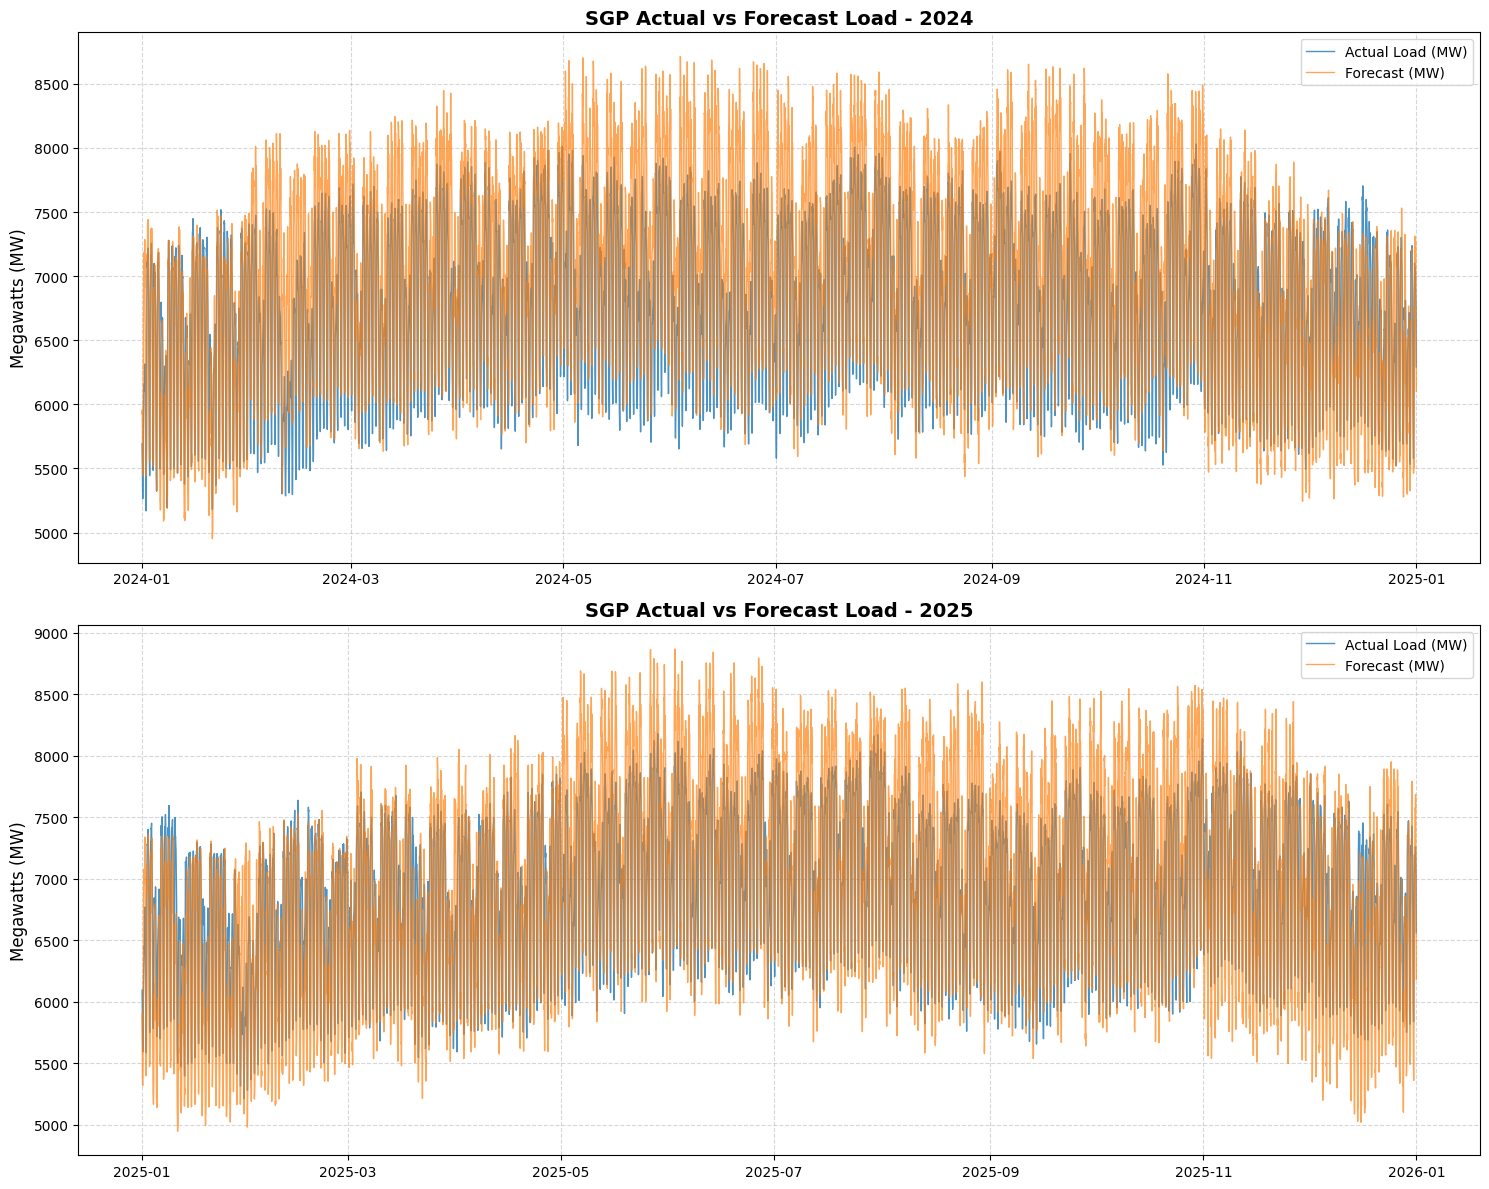

In [256]:
#Create the comparison graph
import matplotlib.pyplot as plt
from datetime import datetime 

df['Time (LOCAL)'] = pd.to_datetime(df['Time (LOCAL)'])

df['Year'] = df['Time (LOCAL)'].dt.year
years = sorted(df['Year'].unique())

fig, axes = plt.subplots(nrows=len(years), ncols=1, figsize=(15, 6 * len(years)), sharex=False)

if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    # Filter data for the specific year
    yearly_data = df[df['Year'] == year]
    
    # Plot Actual Load (Blue)
    axes[i].plot(yearly_data['Time (LOCAL)'], yearly_data['Load (MW)'], 
                 label='Actual Load (MW)', color='#1f77b4', alpha=0.8, linewidth=1)
    
    # Plot Forecast Load (Red/Orange)
    axes[i].plot(yearly_data['Time (UTC)'], yearly_data['Forecast Load (MW)'], 
                 label='Forecast (MW)', color='#ff7f0e', alpha=0.7, linewidth=1)
    
    # Formatting
    entity = df['Entity code'].unique().item()
    axes[i].set_title(f'{entity} Actual vs Forecast Load - {year}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Megawatts (MW)', fontsize=12)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Adjust layout to prevent overlapping text
plt.tight_layout()
# Save the high-resolution image to your folder
time_current = datetime.now().strftime('%Y%m%d-%H%M%S')
#plt.savefig(f"Actual_vs_Forecast_{entity}_{time_current}.png", dpi=300)
plt.show()

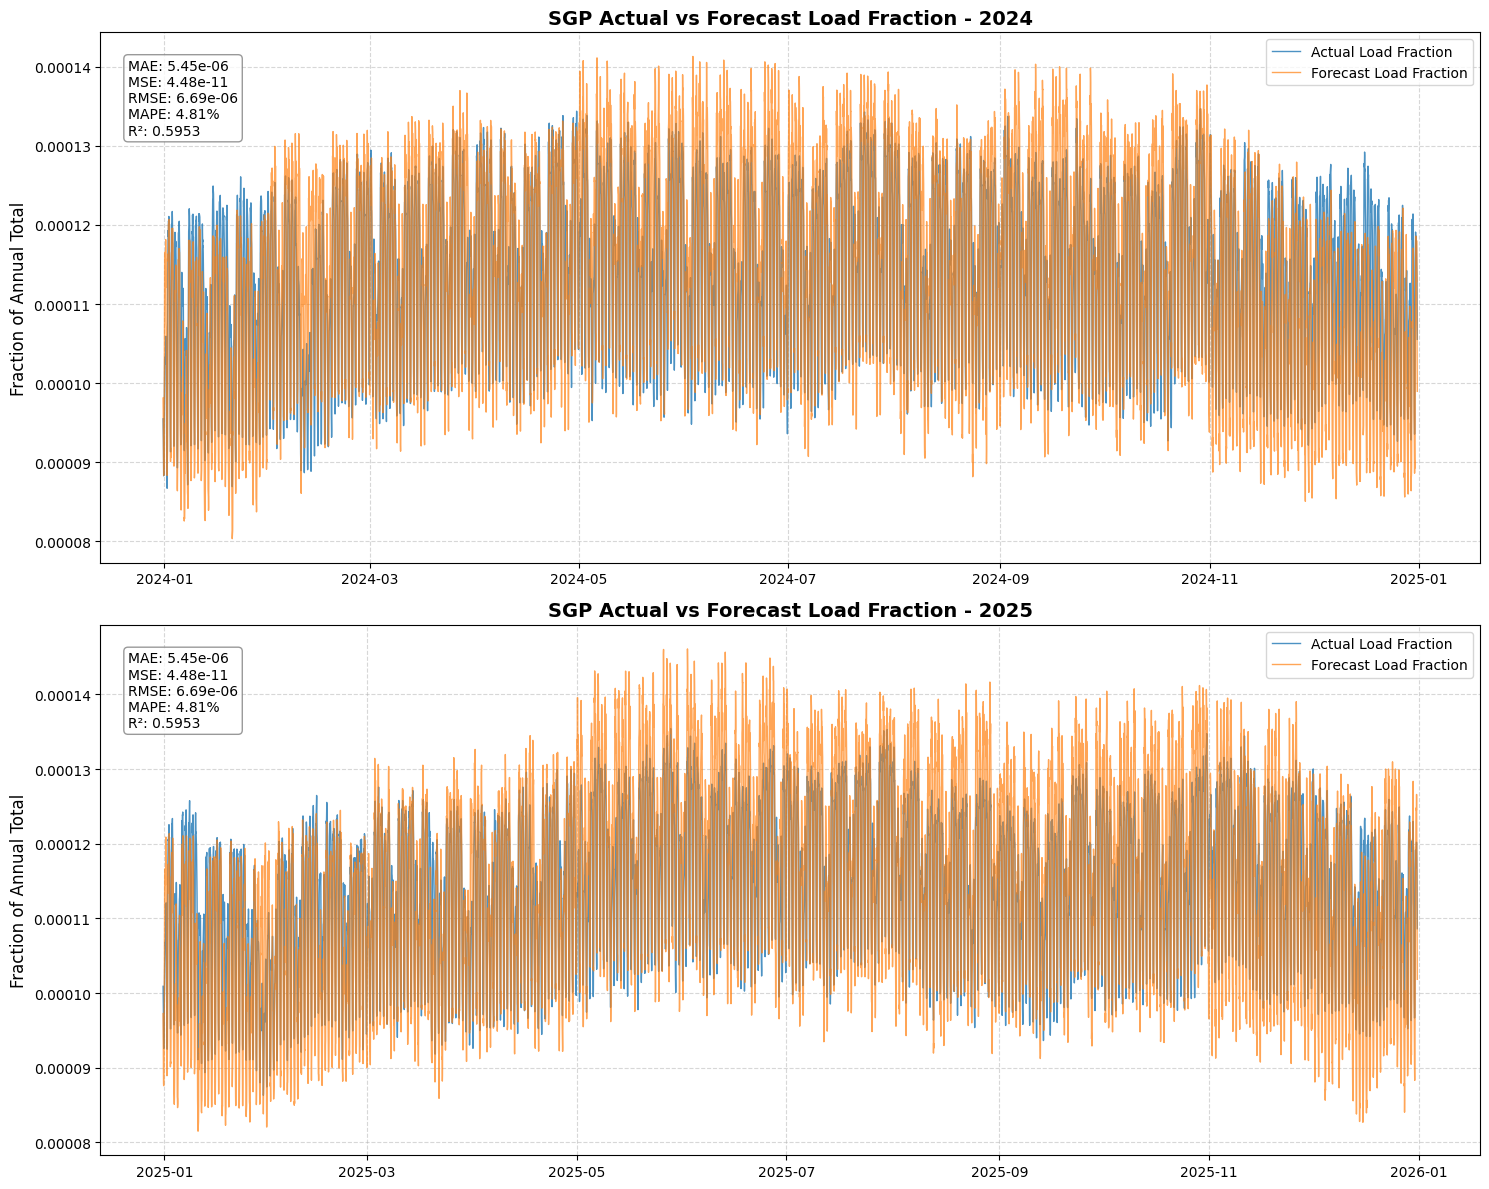

In [257]:
fig2, axes2 = plt.subplots(nrows = len(years),ncols = 1,figsize = (15, 6 * len(years)), sharex=False)

if len(years) == 1:
    axes2 = [axes2]

for i, year in enumerate(years):
    yearly_data = df[df['Year'] == year]
    axes2[i].plot(yearly_data['Time (UTC)'], yearly_data['Load (fraction of annual total)'], 
                 label='Actual Load Fraction', color='#1f77b4', alpha=0.8, linewidth=1)
    
    # Plot Forecast Load Fraction (Orange)
    axes2[i].plot(yearly_data['Time (UTC)'], yearly_data['Normalized forecast load fraction (%)'], 
                 label='Forecast Load Fraction', color='#ff7f0e', alpha=0.7, linewidth=1)

    entity = df['Entity code'].unique().item()
    axes2[i].set_title(f'{entity} Actual vs Forecast Load Fraction - {year}', fontsize=14, fontweight='bold')
    axes2[i].set_ylabel('Fraction of Annual Total', fontsize=12)
    axes2[i].legend(loc='upper right')
    axes2[i].grid(True, linestyle='--', alpha=0.5)

    # Error metrics
    y_true = df['Load (fraction of annual total)']
    y_pred = df['Normalized forecast load fraction (%)']

    # Calculations
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse) # Or root_mean_squared_error(y_true, y_pred) in newer versions
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)   

    #Format the text
    metrics_text = (f"MAE: {mae:.2e}\n"
                    f"MSE: {mse:.2e}\n"
                    f"RMSE: {rmse:.2e}\n"
                    f"MAPE: {mape * 100:.2f}%\n"
                    f"R²: {r2:.4f}")

    axes2[i].text(0.02, 0.95, metrics_text, transform=axes2[i].transAxes, 
                  fontsize=10, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
time_current = datetime.now().strftime('%Y%m%d-%H%M%S')
plt.savefig(f"Actual_vs_Forecast_Fraction_{entity}_{time_current}.png", dpi=300)
plt.show()


In [258]:
# Error metrics
y_true = df['Load (fraction of annual total)']
y_pred = df['Normalized forecast load fraction (%)']

# Calculations
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse) # Or root_mean_squared_error(y_true, y_pred) in newer versions
mape = mean_absolute_percentage_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Displaying results
print(f"MSE:  {mse:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape * 100:.2f}%")
print(f"R2 Score: {r2:.4f}")

MSE:  0.00 MW
RMSE: 0.00 MW
MAPE: 4.81%
R2 Score: 0.5953
